# Reviewer 1 comment 3

Reviewer comment copy-pasted:
> Because the reported gains are very large, the paper would be stronger if it included confidence intervals rather than a single 10 times split. A plot showing fold-to-fold variability would make the improvement much more convincing. 

Relevant sections from the paper:
- table 1
- figure 6

Tasks:
- add SEM column for standard error of the MSE in table 1
- add 95% error bars for the line plots in figure 6

In [24]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from whecho.whecho import whecho_simple

from matplotlib import rcParams
from matplotlib.ticker import MaxNLocator

Step 1: added wv_457_275 -> 10-fold MSE: 22157.58
Step 2: added wv_427_16 -> 10-fold MSE: 6753.58
Step 3: added wv_631_853 -> 10-fold MSE: 6861.90
Step 4: added wv_423_564 -> 10-fold MSE: 4697.08
Step 5: added wv_478_19 -> 10-fold MSE: 3205.72
Step 6: added wv_479_65 -> 10-fold MSE: 2388.56
Step 7: added wv_545_117 -> 10-fold MSE: 1975.39
Step 8: added wv_629_068 -> 10-fold MSE: 3017.36
Step 9: added wv_452_447 -> 10-fold MSE: 2759.62
Step 10: added wv_547_774 -> 10-fold MSE: 8.81
Step 11: added wv_631_058 -> 10-fold MSE: 18.37
Step 12: added wv_488_603 -> 10-fold MSE: 3.87
Step 13: added wv_455_176 -> 10-fold MSE: 32.14
Step 14: added wv_633_841 -> 10-fold MSE: 70.15
Step 15: added wv_633_046 -> 10-fold MSE: 29.79
Step 16: added wv_635_827 -> 10-fold MSE: 72.23
Step 17: added wv_421_447 -> 10-fold MSE: 115.99
Step 18: added wv_419_329 -> 10-fold MSE: 166.32
Step 19: added wv_417_21 -> 10-fold MSE: 213.04


findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Fo

Step 20: added wv_415_089 -> 10-fold MSE: 295.73


findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Fo

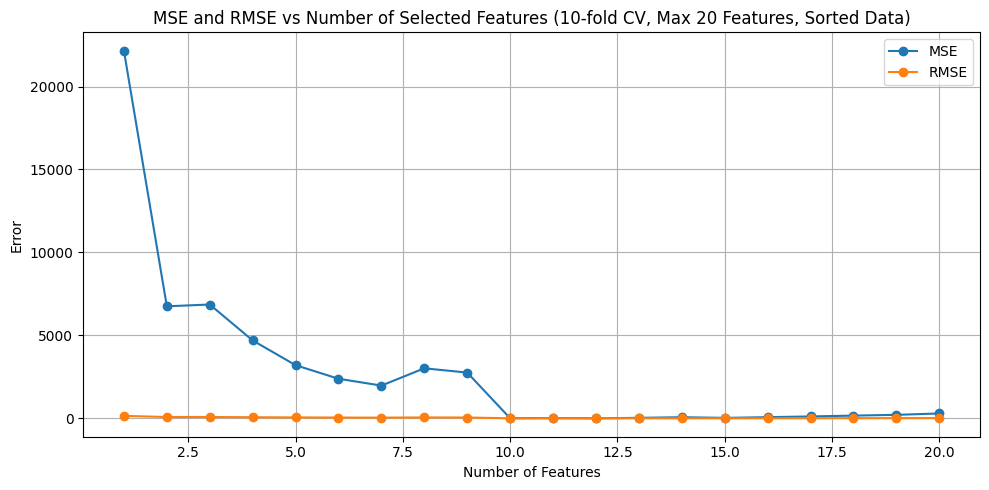

In [13]:
# === Load preprocessed sorted data ===
df = pd.read_csv("..\..\p11_new_paper_test\ML_colorimetric_data\ML colorimetric data\processed_sorted_transmission.csv", index_col=0)

# === Prepare X and y ===
X = df.copy()
y = X.index.values
X.reset_index(drop=True, inplace=True)

# === Optional: rename columns to valid variable names ===
X.columns = [f"wv_{str(c).replace('.', '_')}" for c in X.columns]

# === Define 10-fold CV MSE ===
def kfold_cv_mse(X_vals, y_vals, n_splits=10):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    mse_vals = []
    for train_idx, val_idx in kf.split(X_vals):
        X_train, X_val = X_vals[train_idx], X_vals[val_idx]
        y_train, y_val = y_vals[train_idx], y_vals[val_idx]
        model = LinearRegression().fit(X_train, y_train)
        y_pred = model.predict(X_val)
        mse_vals.append(mean_squared_error(y_val, y_pred))
    # make a dataframe to store the mse values for each fold
    mse_df = pd.DataFrame({"mse": mse_vals,"fold": range(1, n_splits + 1)})
    return np.mean(mse_vals), np.std(mse_vals) / np.sqrt(n_splits), mse_df

# === Greedy feature selection with a 20-feature cap ===
remaining = list(X.columns)
selected = []
data_list = []

best_mse = float("inf")
best_sem = None
max_features = 20  # Limit number of added features

all_data = []

for i in range(1, max_features + 1):
    best_mse_this_round = float("inf")
    best_candidate = None

    for candidate in remaining:
        test_features = selected + [candidate]
        mse, sem, mse_df = kfold_cv_mse(X[test_features].values, y)
        mse_df["features"] = ", ".join(test_features)
        mse_df["n_feats"] = len(test_features)
        all_data.append(mse_df)
        if mse < best_mse_this_round:
            best_mse_this_round = mse
            best_sem = sem
            best_candidate = candidate

    if best_candidate is None:
        break

    selected.append(best_candidate)
    remaining.remove(best_candidate)
    best_mse = best_mse_this_round
    data_list.append({
        "n_feats": len(selected),
        "features": ", ".join(selected),
        "mse": best_mse,
        "rmse": np.sqrt(best_mse),
        "sem": best_sem
    })

    print(f"Step {len(selected)}: added {best_candidate} -> 10-fold MSE: {best_mse:.2f}")

# === Convert to DataFrame and Plot ===
results_df = pd.DataFrame(data_list)

plt.figure(figsize=(10, 5))
plt.plot(results_df["n_feats"], results_df["mse"], label="MSE", marker="o")
plt.plot(results_df["n_feats"], results_df["rmse"], label="RMSE", marker="o")
plt.xlabel("Number of Features")
plt.ylabel("Error")
plt.title("MSE and RMSE vs Number of Selected Features (10-fold CV, Max 20 Features, Sorted Data)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [14]:
results_df

,n_feats,features,mse,rmse,sem
0,1,wv_457_275,22157.579719,148.854223,3112.471847
1,2,"wv_457_275, wv_427_16",6753.581712,82.180178,1868.050842
2,3,"wv_457_275, wv_427_16, wv_631_853",6861.898743,82.836579,1998.102952
3,4,"wv_457_275, wv_427_16, wv_631_853, wv_423_564",4697.081353,68.535256,1250.524254
4,5,"wv_457_275, wv_427_16, wv_631_853, wv_423_564,...",3205.718833,56.619068,956.875609
5,6,"wv_457_275, wv_427_16, wv_631_853, wv_423_564,...",2388.561331,48.872910,701.929761
6,7,"wv_457_275, wv_427_16, wv_631_853, wv_423_564,...",1975.388178,44.445339,628.571548
7,8,"wv_457_275, wv_427_16, wv_631_853, wv_423_564,...",3017.362941,54.930528,1041.942687
8,9,"wv_457_275, wv_427_16, wv_631_853, wv_423_564,...",2759.615685,52.532044,780.877093
9,10,"wv_457_275, wv_427_16, wv_631_853, wv_423_564,...",8.811651,2.968443,3.910286


In [29]:
all_data_df = pd.concat(all_data, ignore_index=True)
selected_features_df_subset = all_data_df[all_data_df.features.isin(results_df.features.tolist())].copy(deep=True)

# 1. Establish baselines per fold
fold_2_feat1_mse = {fold: mse for fold, n_feats, mse in zip(selected_features_df_subset.fold, selected_features_df_subset.n_feats, selected_features_df_subset.mse) if n_feats == 1}
selected_features_df_subset["1feat_baseline_mse"] = selected_features_df_subset.fold.map(fold_2_feat1_mse)

# 2. Calculate Log-Ratios at the fold level
# Log-improvement = ln(Baseline / Current)
selected_features_df_subset["log_mse_imp"] = np.log(selected_features_df_subset["1feat_baseline_mse"] / selected_features_df_subset["mse"])
# Note: RMSE improvement in log space is simply 0.5 * MSE log improvement
selected_features_df_subset["log_rmse_imp"] = 0.5 * selected_features_df_subset["log_mse_imp"]

# 3. Aggregate means and the SEM of the LOG values
summary_df = selected_features_df_subset.groupby("n_feats").agg(
    mean_mse=("mse", "mean"),
    se_mse=("mse", lambda x: np.std(x) / np.sqrt(len(x))),
    # Log-space stats for fold improvement
    mean_log_mse_imp=("log_mse_imp", "mean"),
    se_log_mse_imp=("log_mse_imp", lambda x: np.std(x) / np.sqrt(len(x))),
    mean_log_rmse_imp=("log_rmse_imp", "mean"),
    se_log_rmse_imp=("log_rmse_imp", lambda x: np.std(x) / np.sqrt(len(x)))
).reset_index()

# 4. Transform back to original scale (Exponentiation)
# This gives the geometric mean of fold improvement, which is robust for ratios
summary_df["mean_mse_fold_improvement"] = np.exp(summary_df["mean_log_mse_imp"])
summary_df["mean_rmse_fold_improvement"] = np.exp(summary_df["mean_log_rmse_imp"])

# 5. Calculate Asymmetric Error Bars (95% CI)
z = 1.96

# MSE Fold Improvement Bounds
summary_df["mse_imp_low"] = np.exp(summary_df["mean_log_mse_imp"] - z * summary_df["se_log_mse_imp"])
summary_df["mse_imp_high"] = np.exp(summary_df["mean_log_mse_imp"] + z * summary_df["se_log_mse_imp"])

# RMSE Fold Improvement Bounds
summary_df["rmse_imp_low"] = np.exp(summary_df["mean_log_rmse_imp"] - z * summary_df["se_log_rmse_imp"])
summary_df["rmse_imp_high"] = np.exp(summary_df["mean_log_rmse_imp"] + z * summary_df["se_log_rmse_imp"])

# Standard RMSE for the RMSE-specific plot (Panel b/d)
summary_df["mean_rmse"] = np.sqrt(summary_df["mean_mse"])
# Delta method approximation for RMSE SEM
summary_df["se_rmse"] = summary_df["se_mse"] / (2 * summary_df["mean_rmse"])
summary_df

,n_feats,mean_mse,se_mse,mean_log_mse_imp,se_log_mse_imp,mean_log_rmse_imp,se_log_rmse_imp,mean_mse_fold_improvement,mean_rmse_fold_improvement,mse_imp_low,mse_imp_high,rmse_imp_low,rmse_imp_high,mean_rmse,se_rmse
0,1,22157.579719,3112.471847,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,148.854223,10.454765
1,2,6753.581712,1868.050842,2.179850,0.584271,1.089925,0.292136,8.844981,2.974051,2.814201,27.799607,1.677558,5.272533,82.180178,11.365580
2,3,6861.898743,1998.102952,1.978441,0.597250,0.989221,0.298625,7.231462,2.689138,2.243040,23.313911,1.497678,4.828448,82.836579,12.060511
3,4,4697.081353,1250.524254,2.216043,0.601198,1.108022,0.300599,9.170971,3.028361,2.822702,29.796520,1.680090,5.458619,68.535256,9.123219
4,5,3205.718833,956.875609,2.569630,0.491247,1.284815,0.245624,13.060995,3.614000,4.986755,34.208540,2.233104,5.848807,56.619068,8.450118
5,6,2388.561331,701.929761,2.797543,0.542095,1.398772,0.271047,16.404299,4.050222,5.669141,47.467694,2.380996,6.889680,48.872910,7.181174
6,7,1975.388178,628.571548,2.881169,0.425938,1.440585,0.212969,17.835116,4.223164,7.739447,41.100013,2.781986,6.410929,44.445339,7.071288
7,8,3017.362941,1041.942687,2.908836,0.643493,1.454418,0.321747,18.335448,4.281991,5.194441,64.720848,2.279132,8.044927,54.930528,9.484186
8,9,2759.615685,780.877093,2.811802,0.611095,1.405901,0.305547,16.639872,4.079200,5.023144,55.121922,2.241237,7.424414,52.532044,7.432388
9,10,8.811651,3.910286,8.403379,0.283619,4.201689,0.141810,4462.117696,66.799085,2559.289170,7779.697021,50.589418,88.202591,2.968443,0.658643


In [27]:
selected_features_df_subset

,mse,fold,features,n_feats,1feat_baseline_mse,1feat_baseline_rmse,mse_improvement,rmse_improvement
780,26040.845382,1,wv_457_275,1,26040.845382,161.371761,1.000000,1.000000
781,41233.228075,2,wv_457_275,1,41233.228075,203.059666,1.000000,1.000000
782,31691.673383,3,wv_457_275,1,31691.673383,178.021553,1.000000,1.000000
783,15523.350473,4,wv_457_275,1,15523.350473,124.592738,1.000000,1.000000
784,21964.383871,5,wv_457_275,1,21964.383871,148.203859,1.000000,1.000000
...,...,...,...,...,...,...,...,...
63835,3.450350,6,"wv_457_275, wv_427_16, wv_631_853, wv_423_564,...",20,28426.727491,168.602276,8238.795212,90.767809
63836,22.242065,7,"wv_457_275, wv_427_16, wv_631_853, wv_423_564,...",20,3310.179068,57.534156,148.825165,12.199392
63837,5.560959,8,"wv_457_275, wv_427_16, wv_631_853, wv_423_564,...",20,18288.168704,135.233756,3288.671572,57.346940
63838,0.730348,9,"wv_457_275, wv_427_16, wv_631_853, wv_423_564,...",20,18743.326202,136.906268,25663.559246,160.198500


In [5]:
for v in results_df["sem"]:
    print("{v:.2f}".format(v=v))

3112.47
1868.05
1998.10
1250.52
956.88
701.93
628.57
1041.94
780.88
3.91
7.91
2.87
19.26
17.13
13.24
29.69
59.11
92.54
121.23
156.52


findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Fo

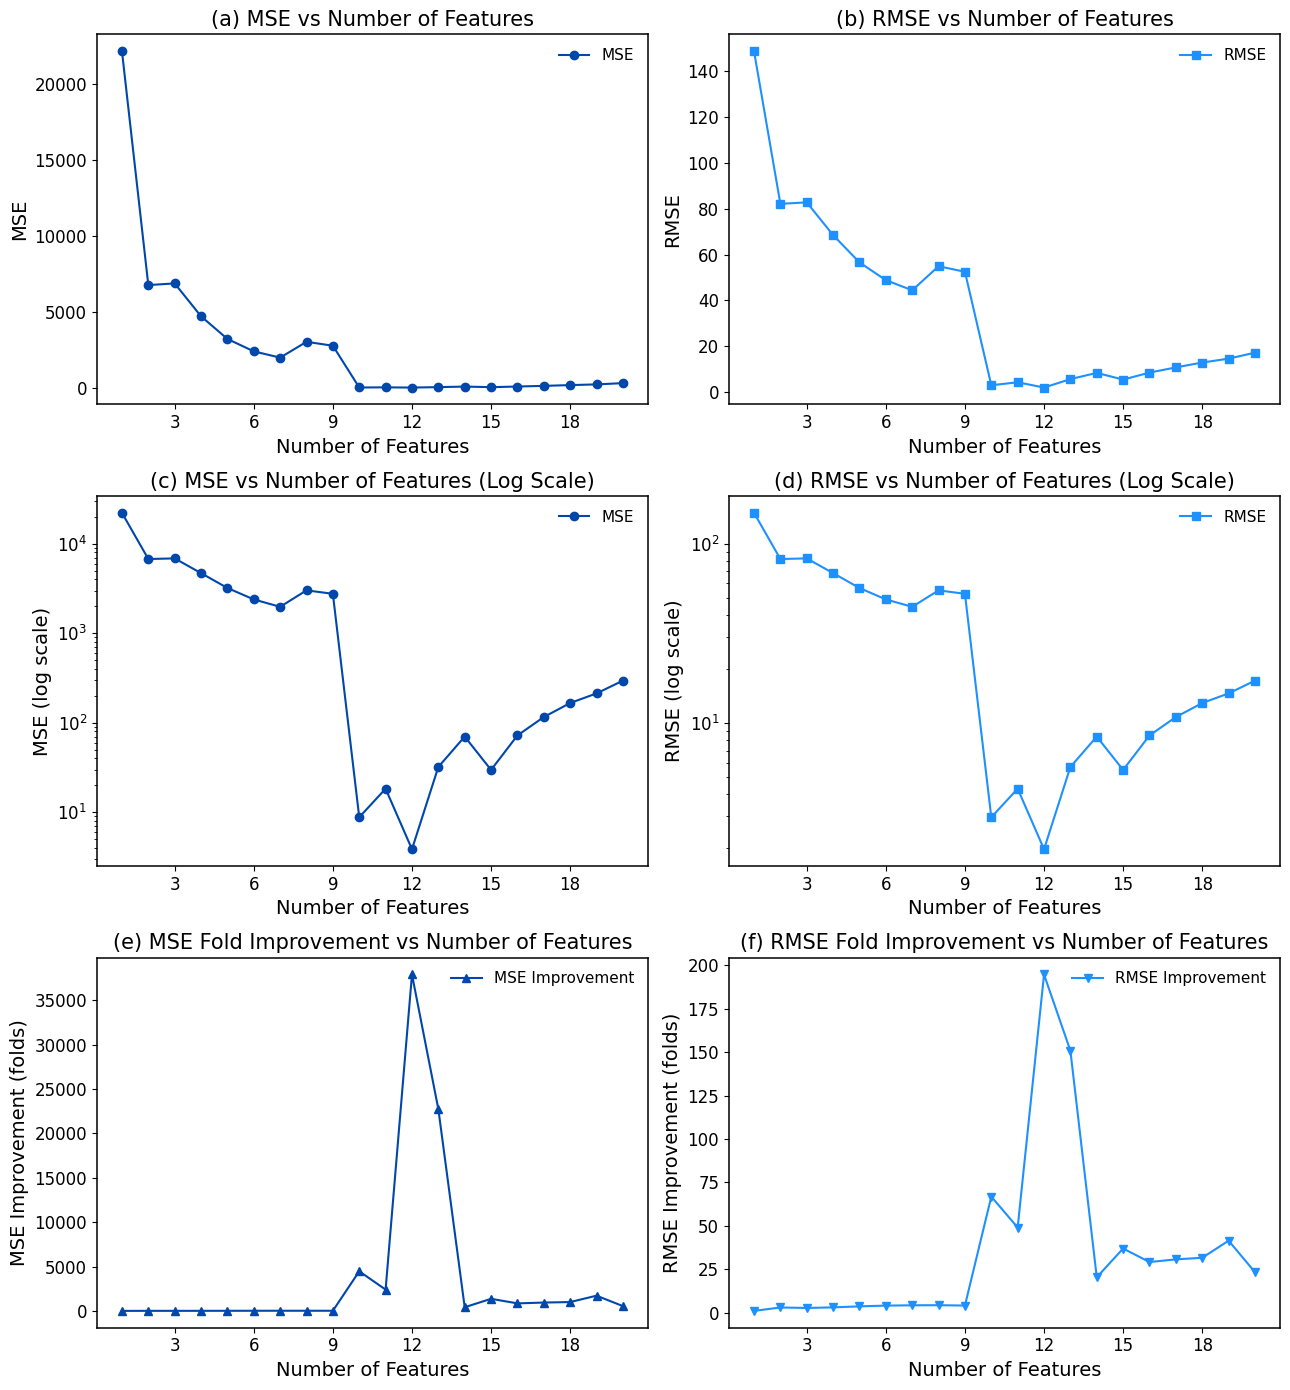

<Figure size 640x480 with 0 Axes>

In [31]:
# Font setup (Liberation Serif ≈ Times New Roman)
rcParams['font.family'] = 'Liberation Serif'
rcParams['axes.facecolor'] = 'white'
rcParams['figure.facecolor'] = 'white'

# Data
df = summary_df.rename(columns={
    "n_feats": "Total features",
    "mean_mse": "MSE",
    "mean_rmse": "RMSE",
    "se_mse": "MSE SEM",
    "se_rmse": "RMSE SEM",
    "mean_mse_fold_improvement": "MSE improvement (folds)",
    "mean_rmse_fold_improvement": "RMSE improvement (folds)",
    "se_mse_fold_improvement": "MSE improvement (folds) SEM",
    "se_rmse_fold_improvement": "RMSE improvement (folds) SEM"
})

# Figure layout
fig, axes = plt.subplots(3, 2, figsize=(13, 14))
axes = axes.flatten()

titles = [
    "(a) MSE vs Number of Features",
    "(b) RMSE vs Number of Features",
    "(c) MSE vs Number of Features (Log Scale)",
    "(d) RMSE vs Number of Features (Log Scale)",
    "(e) MSE Fold Improvement vs Number of Features",
    "(f) RMSE Fold Improvement vs Number of Features"
]

# Panel (a)
axes[0].plot(df["Total features"], df["MSE"], marker="o", color="#0047AB", label="MSE")
axes[0].set_ylabel("MSE", fontsize=14)

# Panel (b)
axes[1].plot(df["Total features"], df["RMSE"], marker="s", color="#1E90FF", label="RMSE")
axes[1].set_ylabel("RMSE", fontsize=14)

# Panel (c)
axes[2].plot(df["Total features"], df["MSE"], marker="o", color="#0047AB", label="MSE")
axes[2].set_yscale("log")
axes[2].set_ylabel("MSE (log scale)", fontsize=14)

# Panel (d)
axes[3].plot(df["Total features"], df["RMSE"], marker="s", color="#1E90FF", label="RMSE")
axes[3].set_yscale("log")
axes[3].set_ylabel("RMSE (log scale)", fontsize=14)

# Panel (e)
axes[4].plot(df["Total features"], df["MSE improvement (folds)"], marker="^", color="#0047AB", label="MSE Improvement")
axes[4].set_ylabel("MSE Improvement (folds)", fontsize=14)

# Panel (f)
axes[5].plot(df["Total features"], df["RMSE improvement (folds)"], marker="v", color="#1E90FF", label="RMSE Improvement")
axes[5].set_ylabel("RMSE Improvement (folds)", fontsize=14)

# Formatting all panels
for ax, title in zip(axes, titles):
    ax.set_xlabel("Number of Features", fontsize=14)
    ax.set_title(title, fontsize=15)  # clean, not bold
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=11, frameon=False, loc='best')
    for spine in ax.spines.values():
        spine.set_linewidth(1.1)
    ax.grid(False)  # no grids

# Increase distance between panels
plt.subplots_adjust(hspace=0.6, wspace=0.5)
plt.tight_layout()

# Save (white background, transparent off)
plt.savefig("Figure6_white_bg_blue_300dpi.png", dpi=300, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()

# Auto-download
plt.savefig("Figure6_white_bg_blue_300dpi.png", dpi=300, bbox_inches="tight", facecolor="white", transparent=False)


findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Fo

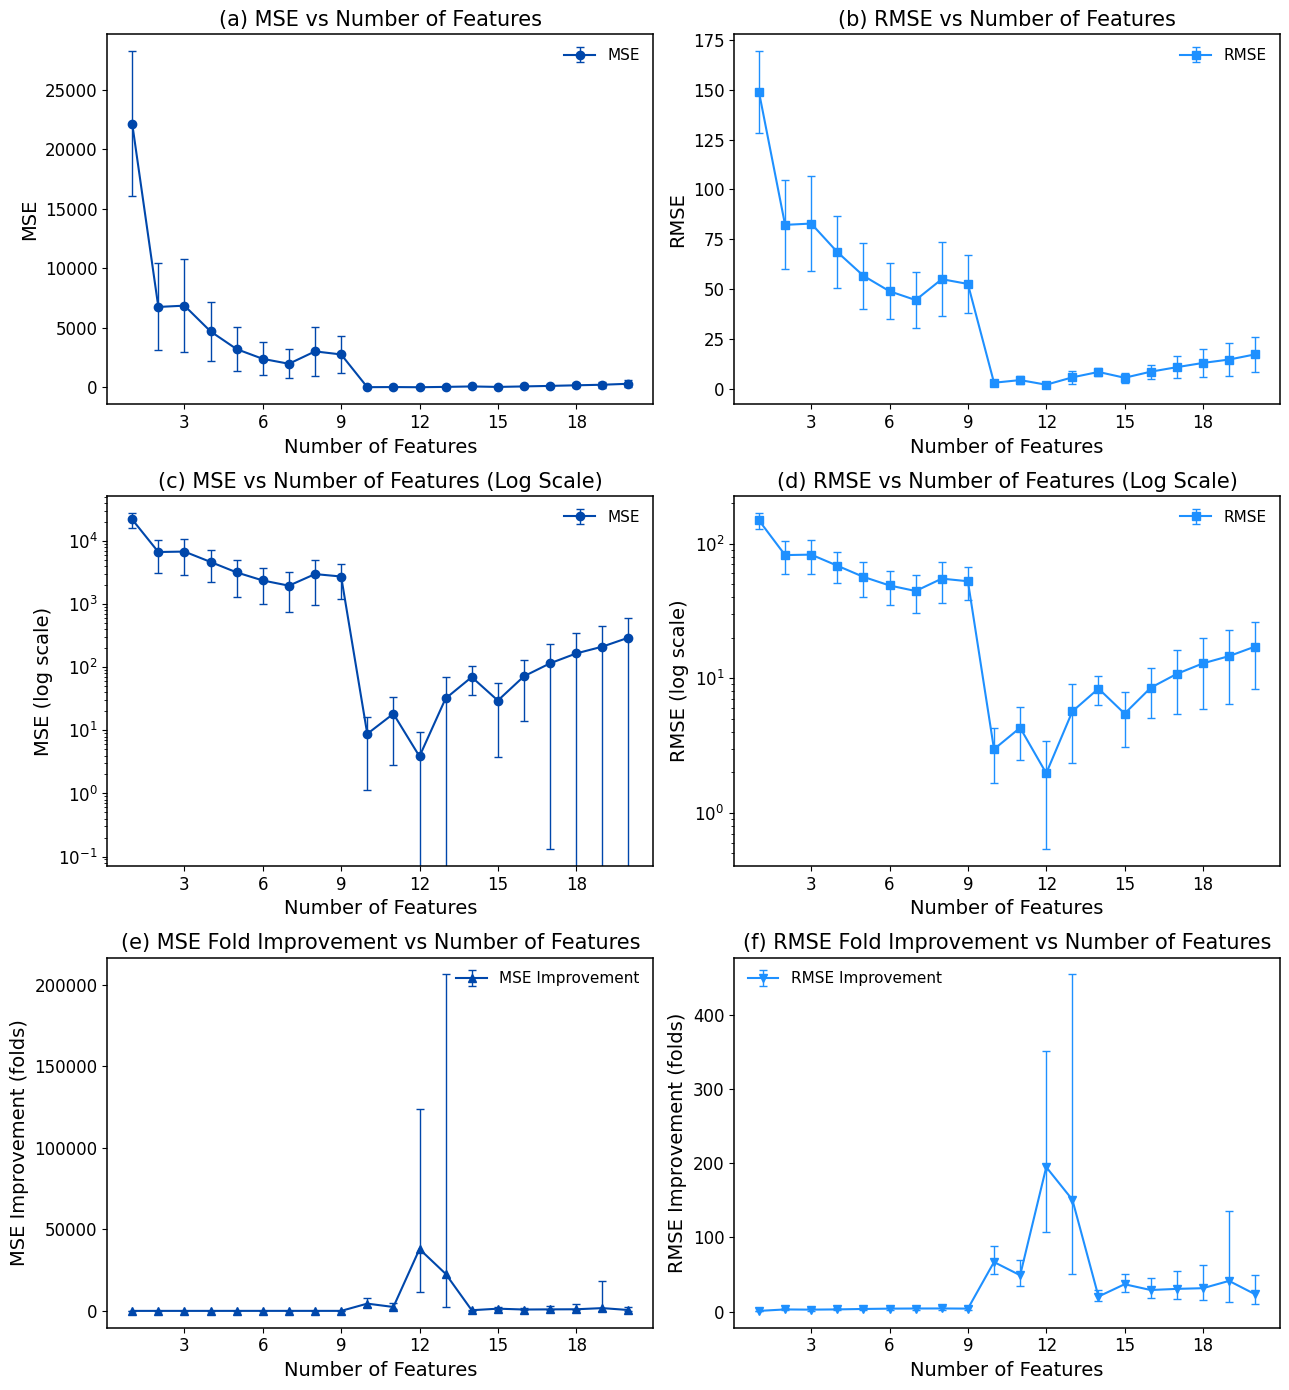

In [32]:
# Font setup
rcParams['font.family'] = 'Liberation Serif'
rcParams['axes.facecolor'] = 'white'
rcParams['figure.facecolor'] = 'white'

# Data Setup (Mapping the new CI columns to the plotting dataframe)
df = summary_df.rename(columns={
    "n_feats": "Total features",
    "mean_mse": "MSE",
    "mean_rmse": "RMSE",
    "se_mse": "MSE SEM",
    "se_rmse": "RMSE SEM",
    "mean_mse_fold_improvement": "MSE improvement (folds)",
    "mean_rmse_fold_improvement": "RMSE improvement (folds)"
})

# Figure layout
fig, axes = plt.subplots(3, 2, figsize=(13, 14))
axes = axes.flatten()

titles = [
    "(a) MSE vs Number of Features",
    "(b) RMSE vs Number of Features",
    "(c) MSE vs Number of Features (Log Scale)",
    "(d) RMSE vs Number of Features (Log Scale)",
    "(e) MSE Fold Improvement vs Number of Features",
    "(f) RMSE Fold Improvement vs Number of Features"
]

z = 1.96

# Panels (a) & (c): MSE with symmetric CI
axes[0].errorbar(df["Total features"], df["MSE"], yerr=df["MSE SEM"]*z, 
                 marker="o", color="#0047AB", label="MSE", capsize=3, elinewidth=1)
axes[2].errorbar(df["Total features"], df["MSE"], yerr=df["MSE SEM"]*z, 
                 marker="o", color="#0047AB", label="MSE", capsize=3, elinewidth=1)

# Panels (b) & (d): RMSE with symmetric CI
axes[1].errorbar(df["Total features"], df["RMSE"], yerr=df["RMSE SEM"]*z, 
                 marker="s", color="#1E90FF", label="RMSE", capsize=3, elinewidth=1)
axes[3].errorbar(df["Total features"], df["RMSE"], yerr=df["RMSE SEM"]*z, 
                 marker="s", color="#1E90FF", label="RMSE", capsize=3, elinewidth=1)

# Panel (e): MSE Fold Improvement (Asymmetric CI)
mse_err_low = df["MSE improvement (folds)"] - summary_df["mse_imp_low"]
mse_err_high = summary_df["mse_imp_high"] - df["MSE improvement (folds)"]
axes[4].errorbar(df["Total features"], df["MSE improvement (folds)"], 
                 yerr=[mse_err_low, mse_err_high], 
                 marker="^", color="#0047AB", label="MSE Improvement", capsize=3, elinewidth=1)

# Panel (f): RMSE Fold Improvement (Asymmetric CI)
rmse_err_low = df["RMSE improvement (folds)"] - summary_df["rmse_imp_low"]
rmse_err_high = summary_df["rmse_imp_high"] - df["RMSE improvement (folds)"]
axes[5].errorbar(df["Total features"], df["RMSE improvement (folds)"], 
                 yerr=[rmse_err_low, rmse_err_high], 
                 marker="v", color="#1E90FF", label="RMSE Improvement", capsize=3, elinewidth=1)

# Apply specific y-axis formatting
axes[2].set_yscale("log")
axes[3].set_yscale("log")

# Labeling
axes[0].set_ylabel("MSE", fontsize=14)
axes[1].set_ylabel("RMSE", fontsize=14)
axes[2].set_ylabel("MSE (log scale)", fontsize=14)
axes[3].set_ylabel("RMSE (log scale)", fontsize=14)
axes[4].set_ylabel("MSE Improvement (folds)", fontsize=14)
axes[5].set_ylabel("RMSE Improvement (folds)", fontsize=14)

# Formatting all panels
for ax, title in zip(axes, titles):
    ax.set_xlabel("Number of Features", fontsize=14)
    ax.set_title(title, fontsize=15)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=11, frameon=False, loc='best')
    for spine in ax.spines.values():
        spine.set_linewidth(1.1)
    ax.grid(False)

# Layout adjustments
plt.subplots_adjust(hspace=0.6, wspace=0.5)
plt.tight_layout()

# Save
plt.savefig("Figure6_white_bg_blue_300dpi.png", dpi=300, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()

findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Fo

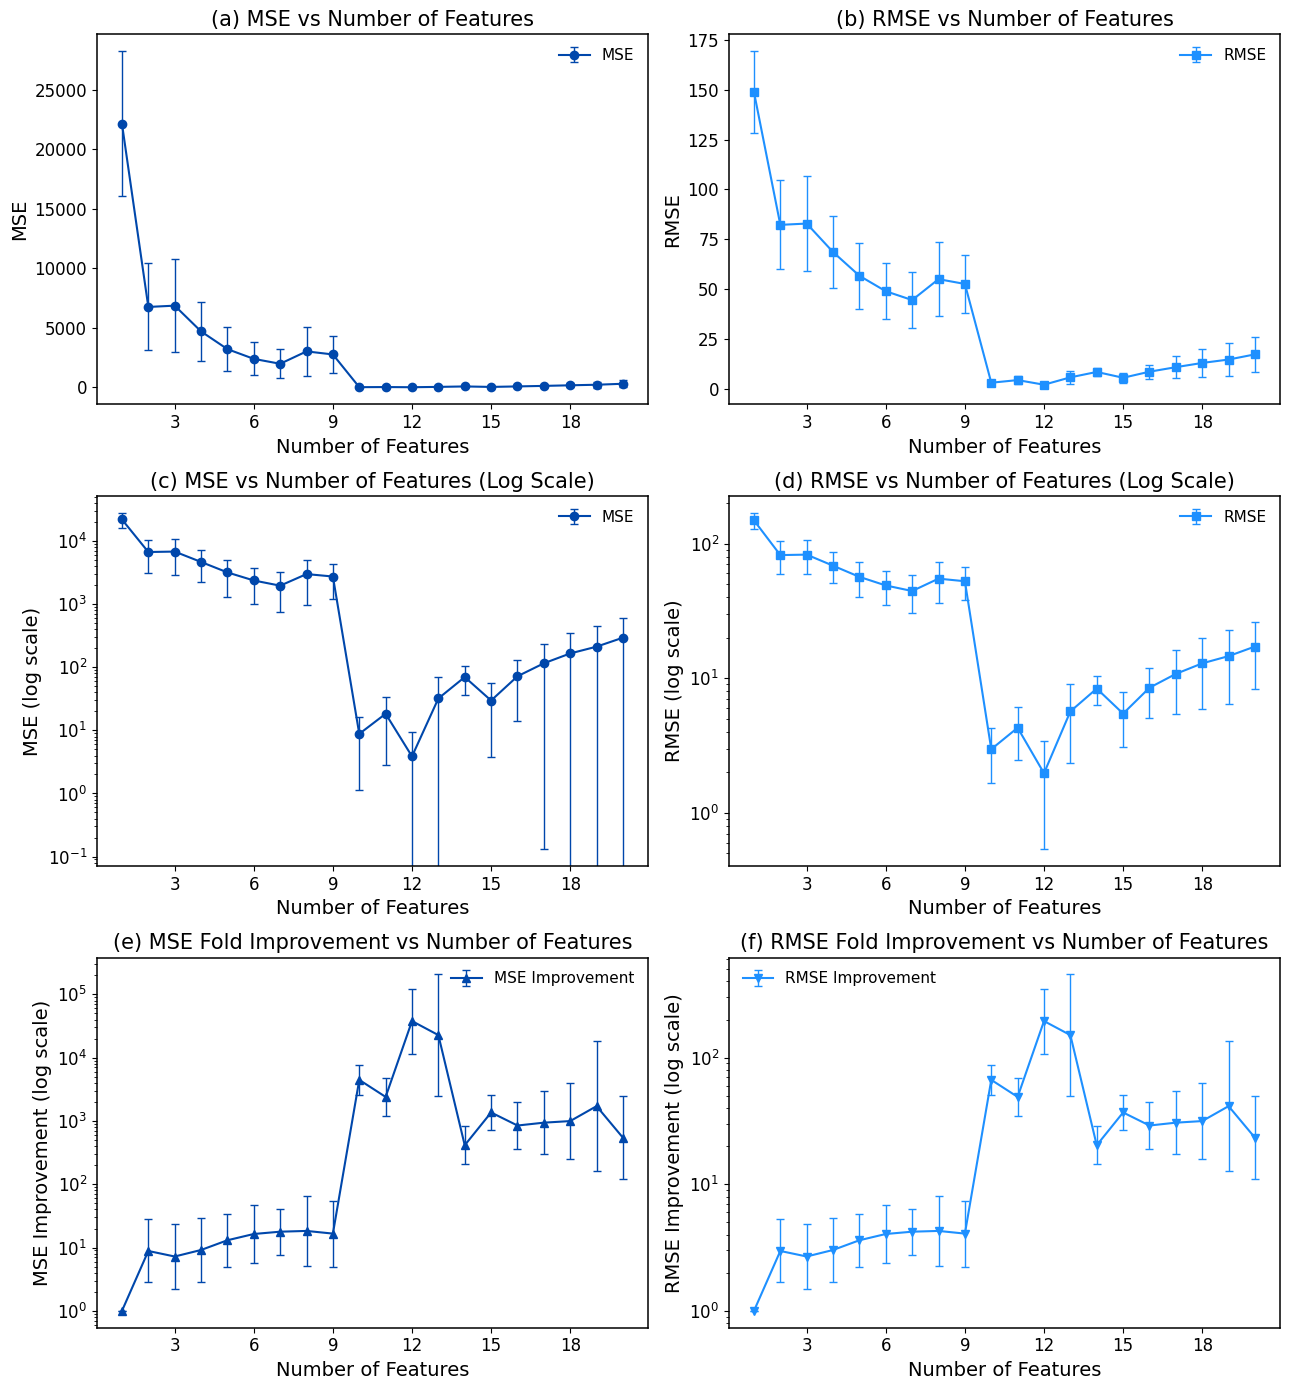

: 

In [ ]:
# redo but with log y-scale for e and f

# Font setup
rcParams['font.family'] = 'Liberation Serif'
rcParams['axes.facecolor'] = 'white'
rcParams['figure.facecolor'] = 'white'

# Data Setup (Mapping the new CI columns to the plotting dataframe)
df = summary_df.rename(columns={
    "n_feats": "Total features",
    "mean_mse": "MSE",
    "mean_rmse": "RMSE",
    "se_mse": "MSE SEM",
    "se_rmse": "RMSE SEM",
    "mean_mse_fold_improvement": "MSE improvement (folds)",
    "mean_rmse_fold_improvement": "RMSE improvement (folds)"
})

# Figure layout
fig, axes = plt.subplots(3, 2, figsize=(13, 14))
axes = axes.flatten()

titles = [
    "(a) MSE vs Number of Features",
    "(b) RMSE vs Number of Features",
    "(c) MSE vs Number of Features (Log Scale)",
    "(d) RMSE vs Number of Features (Log Scale)",
    "(e) MSE Fold Improvement vs Number of Features",
    "(f) RMSE Fold Improvement vs Number of Features"
]

z = 1.96

# Panels (a) & (c): MSE with symmetric CI
axes[0].errorbar(df["Total features"], df["MSE"], yerr=df["MSE SEM"]*z, 
                 marker="o", color="#0047AB", label="MSE", capsize=3, elinewidth=1)
axes[2].errorbar(df["Total features"], df["MSE"], yerr=df["MSE SEM"]*z, 
                 marker="o", color="#0047AB", label="MSE", capsize=3, elinewidth=1)

# Panels (b) & (d): RMSE with symmetric CI
axes[1].errorbar(df["Total features"], df["RMSE"], yerr=df["RMSE SEM"]*z, 
                 marker="s", color="#1E90FF", label="RMSE", capsize=3, elinewidth=1)
axes[3].errorbar(df["Total features"], df["RMSE"], yerr=df["RMSE SEM"]*z, 
                 marker="s", color="#1E90FF", label="RMSE", capsize=3, elinewidth=1)

# Panel (e): MSE Fold Improvement (Asymmetric CI)
mse_err_low = df["MSE improvement (folds)"] - summary_df["mse_imp_low"]
mse_err_high = summary_df["mse_imp_high"] - df["MSE improvement (folds)"]
axes[4].errorbar(df["Total features"], df["MSE improvement (folds)"], 
                 yerr=[mse_err_low, mse_err_high], 
                 marker="^", color="#0047AB", label="MSE Improvement", capsize=3, elinewidth=1)

# Panel (f): RMSE Fold Improvement (Asymmetric CI)
rmse_err_low = df["RMSE improvement (folds)"] - summary_df["rmse_imp_low"]
rmse_err_high = summary_df["rmse_imp_high"] - df["RMSE improvement (folds)"]
axes[5].errorbar(df["Total features"], df["RMSE improvement (folds)"], 
                 yerr=[rmse_err_low, rmse_err_high], 
                 marker="v", color="#1E90FF", label="RMSE Improvement", capsize=3, elinewidth=1)

# Apply specific y-axis formatting
axes[2].set_yscale("log")
axes[3].set_yscale("log")

axes[4].set_yscale("log")
axes[5].set_yscale("log")

# Labeling
axes[0].set_ylabel("MSE", fontsize=14)
axes[1].set_ylabel("RMSE", fontsize=14)
axes[2].set_ylabel("MSE (log scale)", fontsize=14)
axes[3].set_ylabel("RMSE (log scale)", fontsize=14)
axes[4].set_ylabel("MSE Improvement (log scale)", fontsize=14)
axes[5].set_ylabel("RMSE Improvement (log scale)", fontsize=14)

# Formatting all panels
for ax, title in zip(axes, titles):
    ax.set_xlabel("Number of Features", fontsize=14)
    ax.set_title(title, fontsize=15)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=11, frameon=False, loc='best')
    for spine in ax.spines.values():
        spine.set_linewidth(1.1)
    ax.grid(False)

# Layout adjustments
plt.subplots_adjust(hspace=0.6, wspace=0.5)
plt.tight_layout()

# Save
plt.savefig("Figure6_white_bg_blue_300dpi.png", dpi=300, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()